# Eksperiment menggunakan indobenchmark/indobert-base-p1 - Extractive SUmmary

- Menggunakan jumlah data train = 5000, dev =1071 , dan test = 1071
- Epoch = 2

- data dev : ROUGE-1: 0.3028 | ROUGE-2: 0.1458 | ROUGE-L: 0.2453

Sedang mengevaluasi pada Data Dev...


==================================================
HASIL EVALUASI AKHIR (BERTSum Extractive)
==================================================
                     precision    recall  f1-score   support

Bukan Ringkasan (0)       0.87      0.79      0.83     11818
      Ringkasan (1)       0.25      0.37      0.30      2262

           accuracy                           0.73     14080
          macro avg       0.56      0.58      0.56     14080
       weighted avg       0.77      0.73      0.74     14080


Confusion Matrix:
Benar tebak Bukan Ringkasan: 9383
Salah tebak (Bukan Ringkasan dianggap Ringkasan): 2435
Salah tebak (Ringkasan dianggap Bukan Ringkasan): 1435
Benar tebak Ringkasan: 827

In [1]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cek GPU
import torch
print(torch.cuda.is_available())

True


###***Ambil Dataset dari Kaggle***

In [3]:
# Upload ke Google Colab

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nalaprogroup","key":"6e69ae1b1b69e1a4d23d6edf0680d84f"}'}

In [4]:
# Set Permission
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
#Install Kaggle CLI
!pip install kaggle

In [6]:
# Download Dataset
# url : https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2-v2

!kaggle datasets download -d nalaprogroup/clean-data-project2-v2

Dataset URL: https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2-v2
License(s): CC0-1.0
100% 3.82M/3.82M [00:00<00:00, 94.7MB/s]



In [7]:
# Extract File
!unzip clean-data-project2-v2.zip

Archive:  clean-data-project2-v2.zip
  inflating: dev_text_clean.json     
  inflating: test_text_clean.json    
  inflating: train_text_clean.json   


In [8]:
# memindahkan file ke sample_data/liputan6
!mkdir -p /content/sample_data/liputan6

!mv dev_text_clean.json /content/sample_data/liputan6
!mv test_text_clean.json /content/sample_data/liputan6
!mv train_text_clean.json /content/sample_data/liputan6

###***Dataset***

Dataset - 01. Validasi Dataset

In [9]:
# Load 1 sample dulu
import json

with open('/content/sample_data/liputan6/train_text_clean.json') as f:
    data_train = json.load(f)

print("Jml train_text_clean :",len(data_train))

with open('/content/sample_data/liputan6/dev_text_clean.json') as g:
    data_dev = json.load(g)

print("Jml dev_text_clean :",len(data_dev))


with open('/content/sample_data/liputan6/test_text_clean.json') as h:
    data_test = json.load(h)

print("Jml test_text_clean :",len(data_test))


sample = data_train[0]

print("ID:\n", sample['id'])
print("ARTICLE:\n", sample['clean_article'])
print("\nSUMMARY:\n", sample['extractive_summary'])

Jml train_text_clean : 5000
Jml dev_text_clean : 1071
Jml test_text_clean : 1071
ID:
 198679
ARTICLE:
 Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musim tanam para petani harus mengeluarkan b

In [10]:
# pembatasan data untuk testing cek script error biar ga berat
# matikan script jika mau menggunakan semua data set

#data_train=data_train[:10]
#data_dev=data_dev[:10]
#data_test=data_test[:10]

print("Jml data_train :",len(data_train))
print("Jml data_dev :",len(data_dev))
print("Jml data_test :",len(data_test))

Jml data_train : 5000
Jml data_dev : 1071
Jml data_test : 1071


In [11]:
!pip install transformers torch scikit-learn pandas

import json
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report

In [12]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9499b1b649cc5389eae0bc597bf700b3b83b1994af3191206882eb0e8fad7eb7
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [13]:
# Pemecah Kalimat & Pelabelan
import re

def prepare_data_lists(raw_data):
    all_sentences = []
    all_labels = []

    for entry in raw_data:
        article = entry['clean_article']

        # Pecah artikel jadi kalimat berdasarkan titik.
        # Kita pakai regex agar titik yang ada di tengah kata (seperti Liputan6.com) tidak ikut terpecah.
        sentences = re.split(r'(?<=[.!?])\s+', article)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 2]

        # Ambil indeks kalimat yang merupakan ringkasan
        target_indices = entry['extractive_summary']

        for i, sent in enumerate(sentences):
            all_sentences.append(sent)
            # Beri label 1 jika indeks kalimat ini ada di extractive_summary, 0 jika tidak
            label = 1 if i in target_indices else 0
            all_labels.append(label)

    return all_sentences, all_labels

# Eksekusi untuk ketiga split dataset kamu
print("Memproses data train...")
train_sents, train_labels = prepare_data_lists(data_train)
print("Memproses data dev...")
dev_sents, dev_labels = prepare_data_lists(data_dev)
print("Memproses data test...")
test_sents, test_labels = prepare_data_lists(data_test)

print(f"\nSelesai!")
print(f"Total kalimat di Data Train: {len(train_sents)}")
print(f"Contoh label kalimat pertama: {train_labels[0]}") # Seharusnya 1 berdasarkan sample kamu

Memproses data train...
Memproses data dev...
Memproses data test...

Selesai!
Total kalimat di Data Train: 66357
Contoh label kalimat pertama: 1


In [14]:
# Memeriksa Keseimbangan Data
from collections import Counter

counts = Counter(train_labels)
print(f"Distribusi Label: {counts}")
print(f"Rasio Label 1 (Ringkasan): {round(counts[1]/len(train_labels)*100, 2)}%")

Distribusi Label: Counter({0: 55085, 1: 11272})
Rasio Label 1 (Ringkasan): 16.99%


In [15]:
# Persiapan Dataset PyTorch
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
import torch

# Inisialisasi ulang dengan nama yang sangat spesifik agar tidak tertukar
my_tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

# Gunakan nama class baru (V2) untuk menghindari cache lama
class BertSumDatasetV2(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_len=128):
        self.sentences = sentences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, item):
        sentence = str(self.sentences[item])
        label = self.labels[item]

        # MENGGUNAKAN CARA LANGSUNG (Tanpa encode_plus)
        encoding = self.tokenizer(
            sentence,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Re-inisialisasi Loader menggunakan V2
print("Membangun ulang DataLoader...")
train_ds = BertSumDatasetV2(train_sents, train_labels, my_tokenizer, max_len=128)
dev_ds = BertSumDatasetV2(dev_sents, dev_labels, my_tokenizer, max_len=128)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_ds, batch_size=32)

print("✅ Berhasil memperbarui ke V2!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Membangun ulang DataLoader...
✅ Berhasil memperbarui ke V2!


In [16]:
try:
    batch_test = next(iter(dev_loader))
    print("✅ Tes Loader Berhasil! Data siap digunakan.")
except Exception as e:
    print(f"❌ Masih gagal di Loader: {e}")

✅ Tes Loader Berhasil! Data siap digunakan.


In [17]:
try:
    sample_batch = next(iter(train_loader))
    print("✅ Berhasil!")
    print("Bentuk Input IDs:", sample_batch['input_ids'].shape)
except Exception as e:
    print(f"❌ Masih Error: {e}")
    # Jika masih error, kita cek tipe my_tokenizer
    print(f"Tipe tokenizer: {type(my_tokenizer)}")

✅ Berhasil!
Bentuk Input IDs: torch.Size([32, 128])


In [18]:
print(f"Jumlah batch di Train Loader: {len(train_loader)}")

Jumlah batch di Train Loader: 2074


In [19]:
import torch.nn as nn
from torch.optim import AdamW
from transformers import BertForSequenceClassification

# 1. Load Model IndoBERT untuk Klasifikasi (2 Label: 0 atau 1)
model = BertForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p1', num_labels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Tangani Imbalance (Rasio 16.99%)
# Kita beri bobot ~5x lipat lebih besar untuk label 'Ringkasan' (label 1)
# agar model berusaha keras menemukannya.
weights = torch.tensor([1.0, 4.88]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# 3. Optimizer (Learning Rate standar untuk BERT adalah 2e-5)
optimizer = AdamW(model.parameters(), lr=2e-5)

print(f"Model siap di device: {device}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model siap di device: cuda


In [20]:
# Training Loop

from sklearn.metrics import classification_report
import time
import numpy as np

epochs = 2 # Coba 2 epoch dulu agar tidak terlalu lama

for epoch in range(epochs):
    start_time = time.time()

    # --- PHASE TRAINING ---
    model.train()
    total_train_loss = 0

    print(f"\n>>> Memulai Epoch {epoch+1}")

    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

        # Cetak progres setiap 500 batch
        if step % 500 == 0 and step > 0:
            print(f"Batch {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # --- PHASE VALIDATION ---
    model.eval()
    val_preds, val_true = [], []

    print("Sedang mengevaluasi pada Data Dev...")
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_loss = total_train_loss / len(train_loader)
    epoch_mins = (time.time() - start_time) / 60

    print(f"\n✅ Epoch {epoch+1} Selesai dalam {epoch_mins:.2f} menit")
    print(f"Average Train Loss: {avg_loss:.4f}")
    print("\nLaporan Klasifikasi (Data Dev):")
    print(classification_report(val_true, val_preds, target_names=['Bukan Ringkasan', 'Ringkasan']))
    print("-" * 50)

    # --- TAMBAHAN PENILAIAN ROUGE DI BAWAHNYA ---
    from rouge_score import rouge_scorer
    import re # Pastikan re sudah di-import

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1_list, r2_list, rL_list = [], [], []
    #n_sample_rouge = 10 # Gunakan 50 sampel agar training tidak terhenti terlalu lama
    n_sample_rouge = len(data_dev)

    print(f"Menghitung ROUGE pada {n_sample_rouge} sampel Data Dev...")

    model.eval() # Memastikan model dalam mode evaluasi
    for i in range(n_sample_rouge):
        # Ambil data mentah dari dataset dev
        item = data_dev[i]
        article_text = item['clean_article']

        # Pecah artikel menjadi list kalimat
        sentences = re.split(r'(?<=[.!?])\s+', article_text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

        if not sentences: continue

        # Prediksi skor per kalimat
        s_scores = []
        for sent in sentences:
            # Gunakan my_tokenizer (sesuai nama variabel kamu)
            inputs = my_tokenizer(sent, return_tensors="pt", truncation=True, padding="max_length", max_length=128).to(device)
            with torch.no_grad():
                out = model(**inputs)
                # Ambil probabilitas untuk label 1 (Ringkasan)
                prob = torch.softmax(out.logits, dim=1)[0][1].item()
                s_scores.append(prob)

        # Ambil 2 kalimat dengan skor tertinggi
        top_idx = np.argsort(s_scores)[-2:]
        summary_pred = " ".join([sentences[j] for j in sorted(top_idx)])

        # Hitung ROUGE terhadap clean_summary asli
        scores = scorer.score(item['clean_summary'], summary_pred)
        r1_list.append(scores['rouge1'].fmeasure)
        r2_list.append(scores['rouge2'].fmeasure)
        rL_list.append(scores['rougeL'].fmeasure)

    print(f"Hasil ROUGE Epoch {epoch+1}:")
    print(f"ROUGE-1: {np.mean(r1_list):.4f} | ROUGE-2: {np.mean(r2_list):.4f} | ROUGE-L: {np.mean(rL_list):.4f}")
    print("-" * 50)
    # --- AKHIR TAMBAHAN ROUGE ---


>>> Memulai Epoch 1
Batch 500/2074 | Loss: 0.6833
Batch 1000/2074 | Loss: 0.6558
Batch 1500/2074 | Loss: 0.7590
Batch 2000/2074 | Loss: 0.7160
Sedang mengevaluasi pada Data Dev...

✅ Epoch 1 Selesai dalam 25.85 menit
Average Train Loss: 0.6677

Laporan Klasifikasi (Data Dev):
                 precision    recall  f1-score   support

Bukan Ringkasan       0.87      0.83      0.85     11818
      Ringkasan       0.27      0.33      0.30      2262

       accuracy                           0.75     14080
      macro avg       0.57      0.58      0.57     14080
   weighted avg       0.77      0.75      0.76     14080

--------------------------------------------------
Menghitung ROUGE pada 1071 sampel Data Dev...
Hasil ROUGE Epoch 1:
ROUGE-1: 0.3071 | ROUGE-2: 0.1504 | ROUGE-L: 0.2515
--------------------------------------------------

>>> Memulai Epoch 2
Batch 500/2074 | Loss: 0.6362
Batch 1000/2074 | Loss: 0.5864
Batch 1500/2074 | Loss: 0.6864
Batch 2000/2074 | Loss: 0.5242
Sedang menge

In [21]:
# Simpan model dan tokenizer

# Tentukan nama folder penyimpanan
output_dir = "TS_indobert_base_p1_v3"

model.save_pretrained(output_dir)
my_tokenizer.save_pretrained(output_dir)

print(f"✅ Model berhasil disimpan di folder: {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model berhasil disimpan di folder: TS_indobert_base_p1_v3


In [22]:
!zip -r TS_indobert_base_p1_v3.zip ./TS_indobert_base_p1_v3

  adding: TS_indobert_base_p1_v3/ (stored 0%)
  adding: TS_indobert_base_p1_v3/model.safetensors (deflated 7%)
  adding: TS_indobert_base_p1_v3/tokenizer.json (deflated 71%)
  adding: TS_indobert_base_p1_v3/config.json (deflated 57%)
  adding: TS_indobert_base_p1_v3/tokenizer_config.json (deflated 42%)


In [23]:
# Tentukan path tujuan
dest_path = "/content/drive/MyDrive/Colab\ Notebooks/Model/TS_indobert_base_p1_v3"

# Buat folder tujuan jika belum ada
!mkdir -p {dest_path}

# Salin file zip ke folder tersebut
!cp TS_indobert_base_p1_v3.zip {dest_path}

# Verifikasi apakah file sudah tersalin
!ls {dest_path}

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_14398/193426532.py:2: SyntaxWarning: invalid escape sequence '\ '
  dest_path = "/content/drive/MyDrive/Colab\ Notebooks/Model/TS_indobert_base_p1_v3"


TS_indobert_base_p1_v3.zip


In [ ]:
#import shutil
#from google.colab import files

# Kompres folder menjadi file .zip
#shutil.make_archive(output_dir, 'zip', output_dir)

# Download file zip-nya
#files.download(f"{output_dir}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Ubah model ke mode evaluasi
model.eval()

val_preds = []
val_true = []

print("Sedang mengevaluasi pada Data Dev...")

# 2. Matikan penghitungan gradien (untuk menghemat memori & mempercepat proses)
with torch.no_grad():
    for batch in dev_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(ids, attention_mask=mask)

        # Ambil prediksi (index dengan nilai logit tertinggi)
        preds = torch.argmax(outputs.logits, dim=1)

        # Simpan hasil untuk dihitung nanti
        val_preds.extend(preds.cpu().numpy())
        val_true.extend(labels.cpu().numpy())

# 3. Cetak Laporan Klasifikasi
print("\n" + "="*50)
print("HASIL EVALUASI AKHIR (BERTSum Extractive)")
print("="*50)

# Pastikan target_names sesuai dengan urutan label [0, 1]
print(classification_report(val_true, val_preds, target_names=['Bukan Ringkasan (0)', 'Ringkasan (1)']))

# 4. Tambahan: Confusion Matrix untuk melihat detail salah tebak
cm = confusion_matrix(val_true, val_preds)
print("\nConfusion Matrix:")
print(f"Benar tebak Bukan Ringkasan: {cm[0][0]}")
print(f"Salah tebak (Bukan Ringkasan dianggap Ringkasan): {cm[0][1]}")
print(f"Salah tebak (Ringkasan dianggap Bukan Ringkasan): {cm[1][0]}")
print(f"Benar tebak Ringkasan: {cm[1][1]}")

Sedang mengevaluasi pada Data Dev...

HASIL EVALUASI AKHIR (BERTSum Extractive)
                     precision    recall  f1-score   support

Bukan Ringkasan (0)       0.87      0.79      0.83     11818
      Ringkasan (1)       0.25      0.37      0.30      2262

           accuracy                           0.73     14080
          macro avg       0.56      0.58      0.56     14080
       weighted avg       0.77      0.73      0.74     14080


Confusion Matrix:
Benar tebak Bukan Ringkasan: 9383
Salah tebak (Bukan Ringkasan dianggap Ringkasan): 2435
Salah tebak (Ringkasan dianggap Bukan Ringkasan): 1435
Benar tebak Ringkasan: 827


<Figure size 1000x500 with 0 Axes>

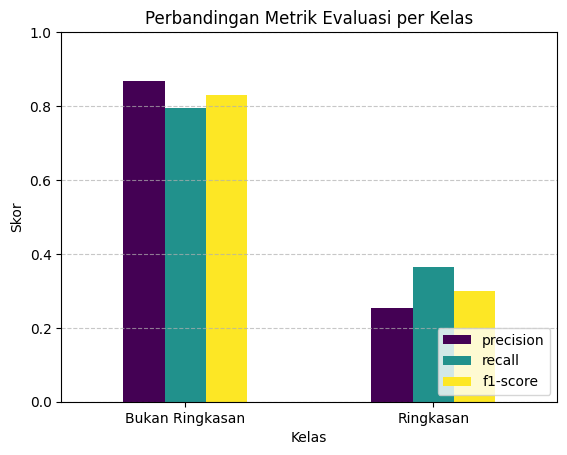

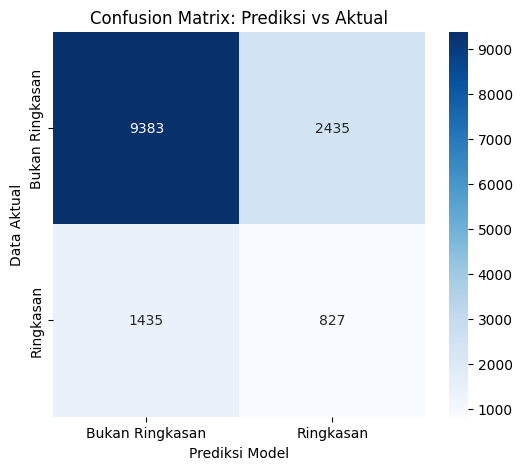

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Ambil data classification report ke dalam DataFrame
report = classification_report(val_true, val_preds,
                               target_names=['Bukan Ringkasan', 'Ringkasan'],
                               output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :2].T # Ambil precision, recall, f1-score

# 2. Visualisasi Perbandingan Metrik
plt.figure(figsize=(10, 5))
df_report.plot(kind='bar', ylim=(0, 1), colormap='viridis')
plt.title('Perbandingan Metrik Evaluasi per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Skor')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Visualisasi Confusion Matrix (Heatmap)
cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Ringkasan', 'Ringkasan'],
            yticklabels=['Bukan Ringkasan', 'Ringkasan'])
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()

#testing model

In [ ]:
!unzip -n -q "/content/TS_indobert_base_p1_v3.zip" -d "/content/TS_indobert_base_p1_v3"

In [26]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

# Tentukan path folder tempat kamu menyimpan model tadi
model_path = "TS_indobert_base_p1_v3"

# Perbaikan: .is_available() bukan .org.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model dan tokenizer
model = BertForSequenceClassification.from_pretrained(model_path).to(device)
my_tokenizer = BertTokenizer.from_pretrained(model_path)

print(f"✅ Model berhasil di-load menggunakan device: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model berhasil di-load menggunakan device: cuda


In [27]:
data_test[1]

{'id': 17402,
 'clean_article': 'Kritikan mantan Ketua Umum Partai Kebangkitan Bangsa Matori Abdul Djalil disambut dingin pengurus partai yang berbasis warga Nahdlatul Ulama itu. Menurut Sekretaris Jenderal PKB Muhaimin Iskandar, permintaan Matori tentang pengunduran diri sejumlah pengurus DPP PKB yang mendorong Presiden mengeluarkan Dekrit hanya sebagai pembelaan diri . " Soalnya, Matori sudah tak mempunyai kekuatan politik, " kata Muhaimin, di Jakarta, Senin (30/7). Menurut Muhaimin, pernyataan Matori tersebut dilakukan untuk mengadu domba para pengurus PKB. Karena itu, tambah Muhaimin, Matori mencoba mencari-cari kesalahan yang dilakukan para pengurus teras partai berbasis nahdliyin itu. Menanggapi pemberhentian Matori, Sekretaris Dewan Syuro PKB Arifin Djunaedi mengatakan, Abdurrahman Wahid sebagai Ketua Umum Dewan Syuro berhak memberhentikan pengurus partai yang ditunjuk. Sebaliknya, Arifin mengungkapkan penunjukan Matori sebagai ketua dalam muktamar 2000 tak didukung para kiai NU

In [28]:
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader

# 1. Siapkan list data dari folder test (asumsi variabel data_test sudah ada)
test_sents, test_labels = prepare_data_lists(data_test)
#test_sents, test_labels = prepare_data_lists([data_test[0]])

# 2. Buat Dataset dan Loader (Gunakan Class V2 yang kita buat tadi)
test_ds = BertSumDatasetV2(test_sents, test_labels, my_tokenizer, max_len=128)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 3. Proses Prediksi
model.eval()
test_preds, test_true = [], []

print("Sedang melakukan testing pada seluruh data test...")
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)

        outputs = model(ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_true.extend(lbls.cpu().numpy())

# 4. Tampilkan Laporan Akhir
print("\n" + "="*50)
print("HASIL EVALUASI PADA DATA TEST (UNSEEN DATA)")
print("="*50)
print(classification_report(test_true, test_preds, target_names=['Bukan Ringkasan', 'Ringkasan']))

Sedang melakukan testing pada seluruh data test...

HASIL EVALUASI PADA DATA TEST (UNSEEN DATA)
                 precision    recall  f1-score   support

Bukan Ringkasan       0.87      0.79      0.83     11056
      Ringkasan       0.28      0.40      0.33      2263

       accuracy                           0.72     13319
      macro avg       0.57      0.59      0.58     13319
   weighted avg       0.77      0.72      0.74     13319



<Figure size 1000x500 with 0 Axes>

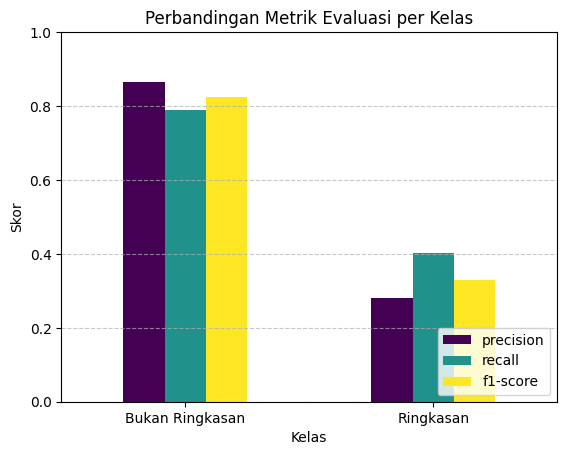

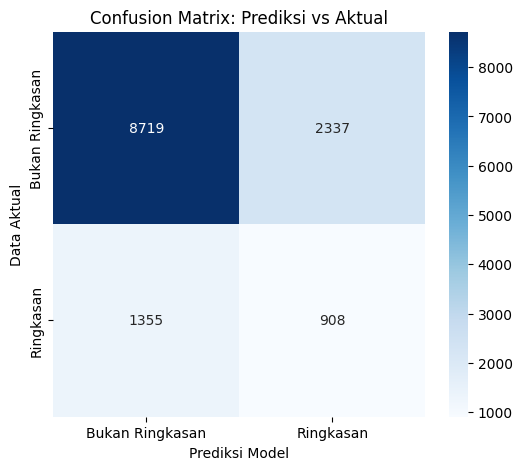

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Ambil data classification report ke dalam DataFrame
report = classification_report(test_true, test_preds,
                               target_names=['Bukan Ringkasan', 'Ringkasan'],
                               output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :2].T # Ambil precision, recall, f1-score

# 2. Visualisasi Perbandingan Metrik
plt.figure(figsize=(10, 5))
df_report.plot(kind='bar', ylim=(0, 1), colormap='viridis')
plt.title('Perbandingan Metrik Evaluasi per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Skor')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Visualisasi Confusion Matrix (Heatmap)
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Ringkasan', 'Ringkasan'],
            yticklabels=['Bukan Ringkasan', 'Ringkasan'])
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()

In [30]:
# Cek Hasil Rangkuman (Inference Satu Berita)
import numpy as np
import pandas as pd
from tqdm import tqdm

def bulk_inference(data_list, model, tokenizer, n_sentences=2):
    model.eval()
    results = []

    # Kita ambil subset data, misal 10 sampai 100
    subset_data = data_list[10:100]

    print(f"Memulai Inference untuk {len(subset_data)} artikel...")

    for item in tqdm(subset_data):
        article_text = item['clean_article']
        sentences = re.split(r'(?<=[.!?])\s+', article_text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

        if not sentences: continue

        sentence_scores = []
        with torch.no_grad():
            for sent in sentences:
                inputs = tokenizer(sent, return_tensors="pt", truncation=True,
                                   padding="max_length", max_length=128).to(device)
                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=1)
                sentence_scores.append(probs[0][1].item())

        # Ambil kalimat terbaik
        ranked_indices = np.argsort(sentence_scores)[::-1]
        top_indices = sorted(ranked_indices[:n_sentences])
        summary_ai = " ".join([sentences[i] for i in top_indices])

        # Simpan perbandingan
        results.append({
            'id': item['id'],
            'asli': item['clean_summary'],
            'prediksi': summary_ai
        })

    return pd.DataFrame(results)

# Jalankan
df_hasil = bulk_inference(data_test, model, my_tokenizer)
print("\nInference Selesai!")

Memulai Inference untuk 90 artikel...


100%|██████████| 90/90 [00:12<00:00,  7.14it/s]


Inference Selesai!


In [31]:
# Tampilkan 5 baris pertama untuk perbandingan
print(df_hasil.head())

# Simpan ke CSV agar bisa dibuka di Excel
#df_hasil.to_csv("hasil_ringkasan_ai_TS_indobert_base_p1_v2.csv", index=False)

      id                                               asli  \
0  17474  Harga singkong di pasaran dan di tingkat pabri...   
1  21775  Pusat penjualan keramik di Rawasari, Jakpus, d...   
2  20929  Secara keseluruhan lawatan Megawati ke AS dan ...   
3  17280  Kehadiran Departemen Sosial di kabinet baru pe...   
4  23500  Latihan perang bersandi Tribuana Sakti III dig...   

                                            prediksi  
0  Sisanya, dijual dalam bentuk gaplek. Bila harg...  
1  Pusat penjualan keramik di Rawasari, Jakarta P...  
2  Dalam kunjungan di kedua negara itu Megawati m...  
3  Perlu atau tidak Departemen Sosial dihidupkan ...  
4  Tiga Kesatuan Komando Pasukan Khusus Angkatan ...  


In [32]:
import re
import numpy as np
import torch
from tqdm import tqdm

def print_bulk_inference(data_list, model, tokenizer, start_idx=10, end_idx=20, n_sentences=2):
    model.eval()

    # Mengambil potongan data sesuai rentang yang kamu mau
    subset_data = data_list[start_idx:end_idx]

    print(f"--- Menampilkan Hasil Inference dari Indeks {start_idx} sampai {end_idx-1} ---\n")

    for item in subset_data:
        article_text = item['clean_article']

        # 1. Pecah artikel menjadi kalimat
        sentences = re.split(r'(?<=[.!?])\s+', article_text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

        if not sentences:
            continue

        # 2. Prediksi skor untuk setiap kalimat
        sentence_scores = []
        with torch.no_grad():
            for sent in sentences:
                inputs = tokenizer(sent, return_tensors="pt", truncation=True,
                                   padding="max_length", max_length=128).to(device)
                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=1)
                sentence_scores.append(probs[0][1].item())

        # 3. Pilih kalimat terbaik (Extractive)
        ranked_indices = np.argsort(sentence_scores)[::-1]
        top_indices = sorted(ranked_indices[:n_sentences])
        summary_ai = " ".join([sentences[i] for i in top_indices])

        # 4. PRINT DENGAN FORMAT SESUAI PERMINTAAN KAMU
        print(f"id : {item['id']}")
        print(f"asli : {item['clean_summary']}")
        print(f"prediksi : {summary_ai}")
        print("======")

# JALANKAN: Misal ingin melihat 10 data (dari indeks 10 sampai 20)
print_bulk_inference(data_test, model, my_tokenizer, start_idx=10, end_idx=20)

--- Menampilkan Hasil Inference dari Indeks 10 sampai 19 ---

id : 17474
asli : Harga singkong di pasaran dan di tingkat pabrik tapioka tak berubah. Keutungan para petani menyusut, mengingat kenaikan harga BBM memicu lonjakan ongkos trasportasi.
prediksi : Sisanya, dijual dalam bentuk gaplek. Bila harga singkong dinaikkan, mereka menilai akan memicu kenaikan biaya produksi dan harga jual tapioka di pasaran internasional.
id : 21775
asli : Pusat penjualan keramik di Rawasari, Jakpus, dikhususkan hanya menjual keramik impor. Para pedagang bisa mengantongi keuntungan hingga Rp 20 juta sehari.
prediksi : Pusat penjualan keramik di Rawasari, Jakarta Pusat yang sudah bertahan sejak 20 tahun memiliki keunikan. Kristal yang diperjualbelikan rata-rata berasal dari Taiwan.
id : 20929
asli : Secara keseluruhan lawatan Megawati ke AS dan Jepang dinilai berhasil baik. Bantuan militer AS tak berkaitan dengan permintaan dukungan Indonesia terhadap invasi militer ke Afghanistan.
prediksi : Dalam kunju

ID (Identitas) : Ini adalah nomor unik atau kode pengenal untuk setiap berita di dalam dataset kamu.

ASLI : Sebagai "kunci jawaban". Model kamu tidak pernah melihat ringkasan ini saat testing. Kita menggunakan ini sebagai standar tertinggi (target) yang ingin dicapai oleh AI.

PREDIKSI : OUTPUT MODEL, Ini adalah hasil ringkasan yang dibuat oleh model AI (IndoBERT) yang baru saja kamu tunning

In [33]:
import re
import numpy as np
import torch
from tqdm import tqdm

def print_full_comparison(data_list, model, tokenizer, start_idx=500, end_idx=510, n_sentences=2):
    model.eval()
    subset_data = data_list[start_idx:end_idx]

    print(f"--- ANALISIS LENGKAP MODEL SUMMARIZATION (Data {start_idx} - {end_idx-1}) ---\n")

    for item in subset_data:
        # 1. Persiapan Teks Artikel
        article_text = item['clean_article']
        sentences = re.split(r'(?<=[.!?])\s+', article_text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

        if not sentences:
            continue

        # 2. Ambil Extractive_Asli (Dari Label Dataset)
        # Mencari kalimat mana yang diberi label 1 di kolom extractive_summary
        labels_asli = item.get('extractive_summary', [])
        extractive_asli_list = [sentences[i] for i, label in enumerate(labels_asli) if label == 1 and i < len(sentences)]
        extractive_asli_str = " ".join(extractive_asli_list)

        # 3. Proses Prediksi Model (Extractive_Prediksi)
        sentence_scores = []
        with torch.no_grad():
            for sent in sentences:
                inputs = tokenizer(sent, return_tensors="pt", truncation=True, padding="max_length", max_length=128).to(device)
                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=1)
                # Ambil skor untuk label 1 (Ringkasan)
                score = probs[0][1].item()
                sentence_scores.append(score)

        # Ambil n_sentences terbaik berdasarkan skor model
        ranked_indices = np.argsort(sentence_scores)[::-1]
        top_indices = sorted(ranked_indices[:n_sentences])
        extractive_pred_list = [sentences[i] for i in top_indices]
        extractive_pred_str = " ".join(extractive_pred_list)

        # 4. CETAK FORMAT SESUAI PERMINTAAN
        print(f"id                   : {item['id']}")
        print(f"clean summary asli   : {item['clean_summary']}")
        print(f"prediktif (Teks AI)  : {extractive_pred_str}")

        # Menampilkan data mentah dari dataset (Indeks/Masking)
        print(f"extractive_asli (Data) : {item.get('extractive_summary', 'Tidak Ada Data')}")

        # Menampilkan indeks yang dipilih model (Angka)
        print(f"extractive_prediksi (Idx): {top_indices}")

        print("-" * 100)

# JALANKAN (Misal untuk 5 data pertama)
print_full_comparison(data_test, model, my_tokenizer, start_idx=10, end_idx=17)

--- ANALISIS LENGKAP MODEL SUMMARIZATION (Data 10 - 16) ---

id                   : 17474
clean summary asli   : Harga singkong di pasaran dan di tingkat pabrik tapioka tak berubah. Keutungan para petani menyusut, mengingat kenaikan harga BBM memicu lonjakan ongkos trasportasi.
prediktif (Teks AI)  : Sisanya, dijual dalam bentuk gaplek. Bila harga singkong dinaikkan, mereka menilai akan memicu kenaikan biaya produksi dan harga jual tapioka di pasaran internasional.
extractive_asli (Data) : [9, 12]
extractive_prediksi (Idx): [np.int64(4), np.int64(14)]
----------------------------------------------------------------------------------------------------
id                   : 21775
clean summary asli   : Pusat penjualan keramik di Rawasari, Jakpus, dikhususkan hanya menjual keramik impor. Para pedagang bisa mengantongi keuntungan hingga Rp 20 juta sehari.
prediktif (Teks AI)  : Pusat penjualan keramik di Rawasari, Jakarta Pusat yang sudah bertahan sejak 20 tahun memiliki keunikan. Kristal

In [ ]:
data_test[0]

{'id': 24543,
 'clean_article': 'Menghidangkan buah kurma selama Ramadan tak sekadar tradisi semata. Sebab selain disunahkan ajaran agama Islam, para medis pun mengamini khasiat yang terkandung pada kurma. Ternyata, buah yang berasal dari kawasan Timur Tengah itu mengandung banyak keuntungan, terutama bila dijadikan makanan pembuka puasa. Kurma terbukti memiliki kandungan kalori yang lebih tinggi dibandingkan jenis makanan lainnya. Menurut pakar gizi Titi Sunardi, baru-baru ini, di Jakarta, dengan menyantap satu hingga tiga butir kurma saat berbuka, sudah cukup untuk mengganti energi yang hilang saat berpuasa. Berdasarkan hasil penelitian dalam kurma, Titi menambahkan, kandungan potasium dalam kurma sangat bermanfaat untuk mengatasi kelelahan otot plus menurunkan tekanan darah tinggi. Sementara kombinasi zat besi dan hidrat arang yang juga dikandungnya, akan sangat baik bagi penderita anemia dan lesu kronis. Lantaran itulah, kurma disarankan disantap saat berbuka, lantaran kaya serat y

In [34]:
# diexcelkan

import pandas as pd
import re
import numpy as np
import torch
from tqdm import tqdm

def export_inference_to_excel(data_list, model, tokenizer, start_idx=0, end_idx=10, n_sentences=2, filename="hasil_evaluasi_model_TS_indobert_base_p1_v3.xlsx"):
    model.eval()
    all_results = []

    # Ambil potongan data yang ingin dievaluasi
    subset_data = data_list[start_idx:end_idx]

    print(f"Sedang memproses {len(subset_data)} data untuk dieksport...")

    for item in tqdm(subset_data):
        article_text = item['clean_article']
        sentences = re.split(r'(?<=[.!?])\s+', article_text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

        if not sentences:
            continue

        # Proses Prediksi Model
        sentence_scores = []
        with torch.no_grad():
            for sent in sentences:
                inputs = tokenizer(sent, return_tensors="pt", truncation=True, padding="max_length", max_length=128).to(device)
                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=1)
                sentence_scores.append(probs[0][1].item())

        # Ambil indeks dan teks prediksi
        ranked_indices = np.argsort(sentence_scores)[::-1]
        top_indices = sorted(ranked_indices[:n_sentences])
        extractive_pred_str = " ".join([sentences[i] for i in top_indices])

        # Simpan ke list dalam bentuk dictionary
        all_results.append({
            'id': item['id'],
            'clean_summary_asli': item['clean_summary'],
            'prediktif_teks': extractive_pred_str,
            'extractive_asli_data': str(item.get('extractive_summary', [])), # Diubah ke string agar aman di Excel
            'extractive_prediksi_idx': str(top_indices)
        })

    # 2. Ubah List menjadi DataFrame Pandas
    df = pd.DataFrame(all_results)

    # 3. Simpan ke Excel (atau .csv jika tidak ada library openpyxl)
    try:
        df.to_excel(filename, index=False)
        print(f"\n✅ Berhasil! File disimpan dengan nama: {filename}")
    except:
        df.to_csv("hasil_evaluasi_model_TS_indobert_base_p1_v3.csv", index=False)
        print(f"\n✅ Berhasil! File disimpan dengan nama: hasil_evaluasi_model.csv")

    return df

# JALANKAN: Misal ambil 100 data pertama
df_hasil = export_inference_to_excel(data_test, model, my_tokenizer, start_idx=0, end_idx=1070)

Sedang memproses 1070 data untuk dieksport...


100%|██████████| 1070/1070 [02:33<00:00,  6.95it/s]



✅ Berhasil! File disimpan dengan nama: hasil_evaluasi_model_TS_indobert_base_p1_v3.xlsx


In [35]:
from rouge_score import rouge_scorer
import pandas as pd

def hitung_rouge_indobert(dataframe):
    # Inisialisasi scorer untuk ROUGE-1, ROUGE-2, dan ROUGE-L
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    print("Sedang menghitung skor ROUGE...")
    for idx, row in dataframe.iterrows():
        # Membandingkan Teks Prediksi dengan Teks Asli (Clean Summary)
        scores = scorer.score(str(row['clean_summary_asli']), str(row['prediktif_teks']))

        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    # Masukkan ke DataFrame baru untuk dirata-rata
    hasil_df = pd.DataFrame({
        'ROUGE-1': rouge1_scores,
        'ROUGE-2': rouge2_scores,
        'ROUGE-L': rougeL_scores
    })

    rata_rata = hasil_df.mean()

    print("\n" + "="*30)
    print("HASIL EVALUASI ROUGE INDOBERT")
    print("="*30)
    print(f"ROUGE-1: {rata_rata['ROUGE-1']:.4f}")
    print(f"ROUGE-2: {rata_rata['ROUGE-2']:.4f}")
    print(f"ROUGE-L: {rata_rata['ROUGE-L']:.4f}")
    print("="*30)

    return rata_rata

# JALANKAN (Gunakan variabel df_hasil yang didapat dari proses sebelumnya)
skor_akhir = hitung_rouge_indobert(df_hasil)

Sedang menghitung skor ROUGE...

HASIL EVALUASI ROUGE INDOBERT
ROUGE-1: 0.3469
ROUGE-2: 0.1857
ROUGE-L: 0.2815


#====batas pakai=====